In [5]:
import numpy as np
import matplotlib.pyplot as plt

In [6]:
filename = "data/air.txt"

data = np.loadtxt(filename, comments='%')

print("Data shape:", data.shape)
print(data[:5])

Data shape: (2100, 12)
[[ 1.85e+03  1.00e+00 -7.53e-01  3.65e-01       nan       nan       nan
        nan       nan       nan       nan       nan]
 [ 1.85e+03  2.00e+00 -2.02e-01  4.16e-01       nan       nan       nan
        nan       nan       nan       nan       nan]
 [ 1.85e+03  3.00e+00 -3.67e-01  3.73e-01       nan       nan       nan
        nan       nan       nan       nan       nan]
 [ 1.85e+03  4.00e+00 -5.96e-01  3.24e-01       nan       nan       nan
        nan       nan       nan       nan       nan]
 [ 1.85e+03  5.00e+00 -6.19e-01  2.67e-01       nan       nan       nan
        nan       nan       nan       nan       nan]]


In [7]:
year = data[:, 0]
month = data[:, 1]
co2 = data[:, 2]
uncertainty = data[:, 3]

print("First years:", year[:5])
print("First months:", month[:5])
print("First CO₂ values:", co2[:5])
print("First uncertainties:", uncertainty[:5])


First years: [1850. 1850. 1850. 1850. 1850.]
First months: [1. 2. 3. 4. 5.]
First CO₂ values: [-0.753 -0.202 -0.367 -0.596 -0.619]
First uncertainties: [0.365 0.416 0.373 0.324 0.267]


In [8]:
# Convert year and month to decimal year
time = year + (month - 1) / 12

# Calculate the mean CO₂ concentration for each calendar month
monthly_mean = np.zeros(12)

for m in range(1, 13):
    monthly_mean[m - 1] = np.mean(co2[month == m])

# Calculate the monthly anomaly
anomaly = np.zeros(len(co2))

for i in range(len(co2)):
    anomaly[i] = co2[i] - monthly_mean[int(month[i]) - 1]

In [9]:
window = 12

moving_average = np.convolve(
    anomaly,
    np.ones(window) / window,
    mode="valid"
)

moving_time = time[window - 1:]

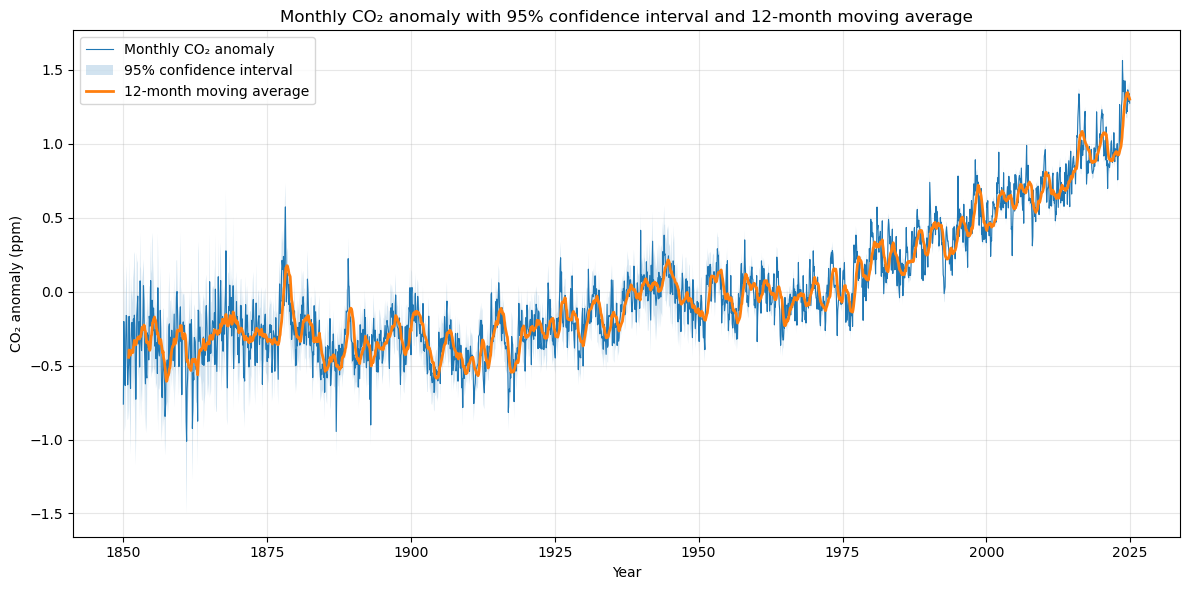

In [10]:
# Calculate the confidence interval
lower = anomaly - uncertainty
upper = anomaly + uncertainty

# Create figure
plt.figure(figsize=(12, 6))

# Monthly CO₂ anomaly
plt.plot(
    time,
    anomaly,
    linewidth=0.8,
    label="Monthly CO₂ anomaly"
)

# 95% confidence interval
plt.fill_between(
    time,
    lower,
    upper,
    alpha=0.2,
    label="95% confidence interval"
)

# 12-month moving average
plt.plot(
    moving_time,
    moving_average,
    linewidth=2,
    label="12-month moving average"
)

# Labels
plt.xlabel("Year")
plt.ylabel("CO₂ anomaly (ppm)")

plt.title(
    "Monthly CO₂ anomaly with 95% confidence interval "
    "and 12-month moving average"
)

plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()